# Part H: Decision Trees and Neural Networks from Scratch

In this notebook, we implement advanced supervised learning models from scratch using NumPy:
1. **Decision Tree Classifier** (Gini/Entropy split)
2. **Regression Tree** (Variance reduction split)
3. **Perceptron Learning Algorithm (PLA)**
4. **Artificial Neural Network (Multilayer Perceptron)** with Backpropagation

We evaluate them using synthetic datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)

## 1. Decision Tree Classifier from Scratch

We build a classification tree that splits nodes based on maximizing Gini impurity reduction or Information Gain.

In [2]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
        
    def fit(self, X, y):
        self.root = self._build_tree(X, y)
        
    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # Stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            most_common = np.argmax(np.bincount(y))
            return Node(value=most_common)
            
        # Greedy search for best split
        best_feat, best_thresh = self._best_split(X, y, n_features)
        
        if best_feat is None:
            most_common = np.argmax(np.bincount(y))
            return Node(value=most_common)
            
        left_idx = X[:, best_feat] < best_thresh
        right_idx = ~left_idx
        
        left_child = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_child = self._build_tree(X[right_idx], y[right_idx], depth + 1)
        
        return Node(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)
        
    def _best_split(self, X, y, n_features):
        best_gain = -1
        split_idx, split_thresh = None, None
        current_entropy = self._entropy(y)
        
        for feat in range(n_features):
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                left_idx = X[:, feat] < thresh
                right_idx = ~left_idx
                
                if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
                    continue
                    
                # Calculate Information Gain
                n = len(y)
                n_l, n_r = np.sum(left_idx), np.sum(right_idx)
                ent_l, ent_r = self._entropy(y[left_idx]), self._entropy(y[right_idx])
                child_entropy = (n_l / n) * ent_l + (n_r / n) * ent_r
                gain = current_entropy - child_entropy
                
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat
                    split_thresh = thresh
                    
        return split_idx, split_thresh
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
        
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] < node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [3]:
# Generate synthetic 2D data for classification
from sklearn.datasets import make_moons # Use standard moons dataset shape generator
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

tree = DecisionTree(max_depth=5)
tree.fit(X, y)
preds = tree.predict(X)
print(f"Decision Tree Classifier Accuracy: {np.mean(preds == y)*100}%")

Decision Tree Classifier Accuracy: 100.0%


## 2. Regression Tree from Scratch

For regression, the objective is to split the data to maximize variance reduction.

In [4]:
class RegressionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        
    def fit(self, X, y):
        self.root = self._build_tree(X, y)
        
    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=np.mean(y))
            
        best_feat, best_thresh = self._best_split(X, y, n_features)
        
        if best_feat is None:
            return Node(value=np.mean(y))
            
        left_idx = X[:, best_feat] < best_thresh
        right_idx = ~left_idx
        
        left_child = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_child = self._build_tree(X[right_idx], y[right_idx], depth + 1)
        
        return Node(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)
        
    def _best_split(self, X, y, n_features):
        best_var_reduction = -1
        split_idx, split_thresh = None, None
        current_variance = np.var(y)
        
        for feat in range(n_features):
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                left_idx = X[:, feat] < thresh
                right_idx = ~left_idx
                
                if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
                    continue
                    
                n = len(y)
                n_l, n_r = np.sum(left_idx), np.sum(right_idx)
                var_l, var_r = np.var(y[left_idx]), np.var(y[right_idx])
                weighted_var = (n_l / n) * var_l + (n_r / n) * var_r
                var_reduction = current_variance - weighted_var
                
                if var_reduction > best_var_reduction:
                    best_var_reduction = var_reduction
                    split_idx = feat
                    split_thresh = thresh
                    
        return split_idx, split_thresh
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
        
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] < node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

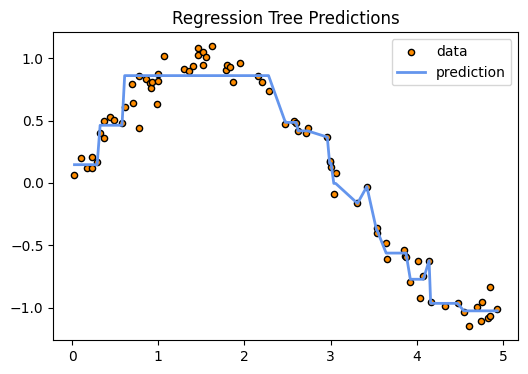

In [5]:
# Generate regression dataset
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0])

reg_tree = RegressionTree(max_depth=4)
reg_tree.fit(X_reg, y_reg)
preds_reg = reg_tree.predict(X_reg)

plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_reg, preds_reg, color="cornflowerblue", label="prediction", linewidth=2)
plt.title('Regression Tree Predictions')
plt.legend()
plt.show()

## 3. Perceptron Learning Algorithm (PLA)

The Perceptron is a simple model for binary classification of linearly separable data.
$$f(x) = \text{step}(w^T x + b)$$

In [6]:
class PerceptronFromScratch:
    def fit(self, X, y, lr=0.1, epochs=1000):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        
        y_temp = np.where(y <= 0, -1, 1)
        
        for epoch in range(epochs):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.w) + self.b
                y_predicted = np.where(linear_output >= 0, 1, -1)
                
                update = lr * (y_temp[idx] - y_predicted)
                if update != 0:
                    self.w += update * x_i
                    self.b += update
                    errors += 1
            if errors == 0:
                break
                
    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.where(linear_output >= 0, 1, 0)

In [7]:
pla = PerceptronFromScratch()
pla.fit(X, y)
pla_preds = pla.predict(X)
print(f"Perceptron Accuracy: {np.mean(pla_preds == y)*100}%")

Perceptron Accuracy: 75.0%


## 4. Artificial Neural Network (Multilayer Perceptron) with Backpropagation

We implement a feedforward neural network with one hidden layer from scratch using NumPy.

In [8]:
class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Initialize weights with Xavier/He initialization
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
        
    def sigmoid_derivative(self, a):
        return a * (1 - a)
        
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
        
    def backward(self, X, y, lr=0.1):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        
        # Backpropagation output layer
        error_output = self.a2 - y
        dW2 = (1 / m) * (self.a1.T @ error_output)
        db2 = (1 / m) * np.sum(error_output, axis=0, keepdims=True)
        
        # Backpropagation hidden layer
        error_hidden = (error_output @ self.W2.T) * self.sigmoid_derivative(self.a1)
        dW1 = (1 / m) * (X.T @ error_hidden)
        db1 = (1 / m) * np.sum(error_hidden, axis=0, keepdims=True)
        
        # Update parameters
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        
    def fit(self, X, y, lr=0.1, epochs=10000, val_split=0.2):
        # Train-validation split
        split_idx = int((1 - val_split) * len(X))
        X_tr, X_val = X[:split_idx], X[split_idx:]
        y_tr, y_val = y[:split_idx], y[split_idx:]
        
        for epoch in range(epochs):
            self.forward(X_tr)
            self.backward(X_tr, y_tr, lr)
            
            if epoch % 2000 == 0:
                # Calculate train and validation accuracy
                train_preds = (self.forward(X_tr) >= 0.5).astype(int).flatten()
                val_preds = (self.forward(X_val) >= 0.5).astype(int).flatten()
                train_acc = np.mean(train_preds == y_tr)
                val_acc = np.mean(val_preds == y_val)
                print(f"Epoch {epoch}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

In [9]:
nn = NeuralNetwork(input_dim=2, hidden_dim=8, output_dim=1)
nn.fit(X, y, lr=0.2, epochs=8000)

Epoch 0: Train Acc = 0.6000, Val Acc = 0.6500
Epoch 2000: Train Acc = 0.9000, Val Acc = 0.8000
Epoch 4000: Train Acc = 0.9125, Val Acc = 0.8000


Epoch 6000: Train Acc = 0.9500, Val Acc = 0.9000
